# 🛰️ Raster Data Processing Using Python — Exercise Notebook

---

> **How to use this notebook:**  
> Each section contains **worked examples** you can run, followed by **practice exercises**.  
> Read the examples carefully, then attempt the exercises in the solution cells.  
> Use `Shift + Enter` to run a cell.

---

## 📋 Table of Contents

| # | Topic |
|---|-------|
| 0 | Setup & Environment |
| 1 | Reading & Exploring Raster Data |
| 2 | Reprojecting a Raster |
| 3 | Visualizing & Analyzing a DEM |
| 4 | Writing Processed Rasters to GeoTIFF |
| 5 | Clipping a Raster with a Vector Boundary |
| 6 | Calculating the Normalized Burn Ratio (NBR) |
| 7 | Overlaying Raster & Vector Data |
| 8 | Bonus — DEM Geomorphology (Slope, Aspect, Hillshade) |

---

# 0️⃣ Setup & Environment

---

> This notebook uses **Google Colab** as the primary environment.  
> All data (DEM and Landsat imagery) will be provided in the `/content/data/` folder.  
> Outputs are written to `/content/output/`.

| Package | Purpose |
|---------|----------|
| `rasterio` | Read/write raster files (GeoTIFF, etc.) |
| `geopandas` | Read/write vector files (Shapefile, GeoJSON) |
| `numpy` | Array maths on raster bands |
| `matplotlib` | Static visualization |
| `rasterio.warp` | Reprojection |
| `rasterio.mask` | Clip raster with vector |

---

### 💡 Example 0.1 — Mount Google Drive & Install Packages

In [1]:
# Mount Google Drive (run once per session)
from google.colab import drive
drive.mount('/content/drive')

# Install rasterio if not already available
# !pip install rasterio

Mounted at /content/drive


### 💡 Example 0.2 — Create Data & Output Folders

In [2]:
import os

data_folder   = 'data'
output_folder = 'output'

for folder in [data_folder, output_folder]:
    if not os.path.exists(folder):
        os.mkdir(folder)
        print(f'Created: {folder}')
    else:
        print(f'Already exists: {folder}')

Created: data
Created: output


### 💡 Example 0.3 — Import All Required Libraries

In [3]:
import geopandas as gpd          # Vector data
import rasterio as rio            # Raster data
import rasterio.plot              # Raster plotting helpers
import rasterio.mask              # Clip raster with vector
import numpy as np                # Array operations
import matplotlib.pyplot as plt   # Visualization
from rasterio.warp import calculate_default_transform, reproject, Resampling

print('All libraries imported successfully ✅')

All libraries imported successfully ✅


# 1️⃣ Reading & Exploring Raster Data

---

> **Rasterio** opens raster files as dataset objects.  
> Key metadata properties describe the grid, projection, and data values.

| Property | Description |
|----------|-------------|
| `src.crs` | Coordinate Reference System |
| `src.res` | Pixel size (x, y) |
| `src.width` / `src.height` | Grid dimensions in pixels |
| `src.count` | Number of bands |
| `src.dtypes` | Data type per band |
| `src.nodata` | NoData sentinel value |
| `src.bounds` | Spatial extent (left, bottom, right, top) |
| `src.transform` | Affine transform (pixel → world) |

---

### 💡 Example 1.1 — Open a DEM and Print Metadata

In [7]:
import rasterio as rio

ND_DEM_PATH = r'data/103_dem_clipped.tif'  # update path as needed

with rio.open(ND_DEM_PATH) as src:
    print(f'File         : {src.name}')
    print(f'CRS          : {src.crs}')
    print(f'Resolution   : {src.res}')
    print(f'Dimensions   : {src.width} x {src.height} pixels')
    print(f'Bands        : {src.count}')
    print(f'Data type    : {src.dtypes[0]}')
    print(f'NoData value : {src.nodata}')
    print(f'Bounds       : {src.bounds}')
    print(f'Transform    :\n{src.transform}')

RasterioIOError: data/103_dem_clipped.tif: No such file or directory

### 💡 Example 1.2 — Read Band Data as a NumPy Array

In [6]:
import rasterio as rio
import numpy as np

ND_DEM_PATH = r'data/103_dem_clipped.tif'

with rio.open(ND_DEM_PATH) as src:
    band = src.read(1).astype(float)   # read band 1 as float
    nodata = src.nodata

# Mask NoData values
if nodata is not None:
    band[band == nodata] = np.nan

print(f'Array shape : {band.shape}')
print(f'Min elev    : {np.nanmin(band):.2f} m')
print(f'Max elev    : {np.nanmax(band):.2f} m')
print(f'Mean elev   : {np.nanmean(band):.2f} m')
print(f'Std dev     : {np.nanstd(band):.2f} m')

RasterioIOError: data/103_dem_clipped.tif: No such file or directory

### 💡 Example 1.3 — Understanding Resolution in WGS 84 vs UTM

In [9]:
# WGS 84 stores resolution in decimal degrees.
# Multiply by 111,111 to convert to approximate metres.

import rasterio as rio

ND_DEM_PATH = r'data/103_dem_clipped.tif'

with rio.open(ND_DEM_PATH) as src:
    res_deg = src.res
    res_m   = (res_deg[0] * 111_111, res_deg[1] * 111_111)

print(f'Resolution (degrees) : {res_deg}')
print(f'Approx. resolution   : {res_m[0]:.1f} m x {res_m[1]:.1f} m')
print('Note: reprojecting to a metric CRS gives exact metre values.')

RasterioIOError: data/103_dem_clipped.tif: No such file or directory

# 2️⃣ Reprojecting a Raster

---

> **Reprojection** transforms a raster from one CRS to another.  
> `rasterio.warp` calculates the new grid dimensions and applies pixel resampling.

| Step | Function |
|------|----------|
| Calculate new grid | `calculate_default_transform(src_crs, dst_crs, w, h, *bounds, resolution=)` |
| Reproject band | `reproject(source=band, destination=dest, ...)` |
| Resampling methods | `Resampling.nearest`, `.bilinear`, `.cubic` |

---

### 💡 Example 2.1 — Reproject DEM from WGS 84 to EPSG:5070 (30 m)

In [10]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling

ND_DEM_PATH  = r'data/103_dem_clipped.tif'
DST_CRS      = 'EPSG:5070'   # CONUS Albers Equal Area
outfile_proj = r'output/ND_DEM_Projected.tif'

with rasterio.open(ND_DEM_PATH) as src:
    transform, width, height = calculate_default_transform(
        src.crs, DST_CRS,
        src.width, src.height,
        *src.bounds,
        resolution=30.0   # force 30 m output pixels
    )
    kwargs = src.meta.copy()
    kwargs.update({'crs': DST_CRS, 'transform': transform,
                   'width': width, 'height': height})

    with rasterio.open(outfile_proj, 'w', **kwargs) as dst:
        for band_idx in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, band_idx),
                destination=rasterio.band(dst, band_idx),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=DST_CRS,
                resampling=Resampling.bilinear
            )

print(f'Reprojected raster saved to: {outfile_proj}')

RasterioIOError: data/103_dem_clipped.tif: No such file or directory

### 💡 Example 2.2 — Verify Metadata After Reprojection

In [ ]:
import rasterio as rio

outfile_proj = r'output/ND_DEM_Projected.tif'

with rio.open(outfile_proj) as src:
    print(f'CRS        : {src.crs}')
    print(f'Resolution : {src.res} m')
    print(f'Dimensions : {src.width} x {src.height}')
    print(f'Bounds     : {src.bounds}')

### 💡 Example 2.3 — Side-by-Side Comparison: Original vs Reprojected

RasterioIOError: data/103_dem_clipped.tif: No such file or directory

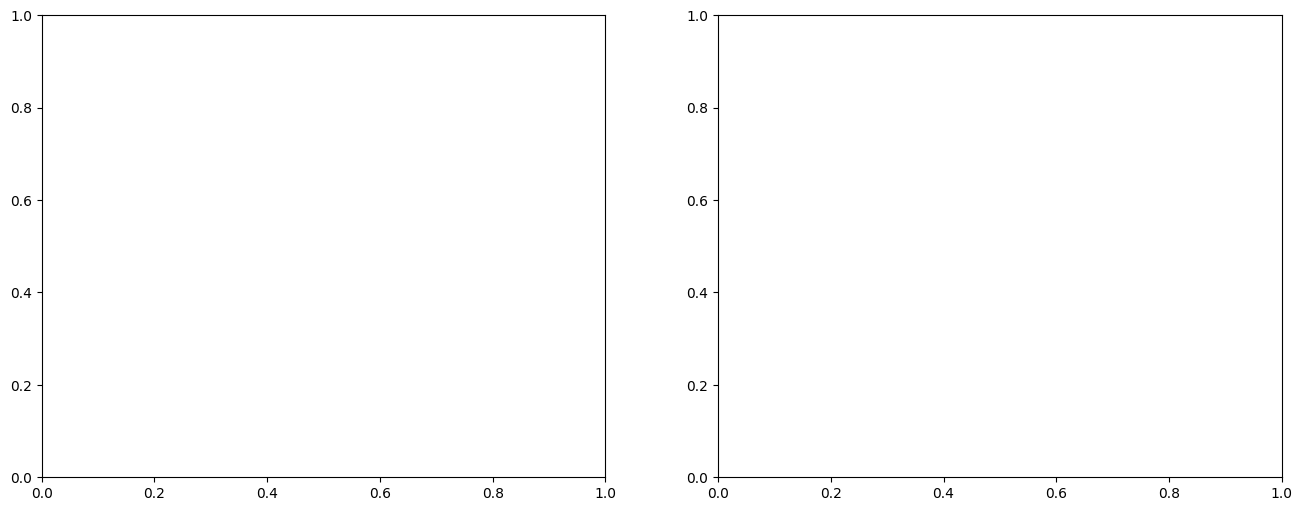

In [11]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

ND_DEM_PATH  = r'data/103_dem_clipped.tif'
outfile_proj = r'output/ND_DEM_Projected.tif'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for ax, path, title in [
    (ax1, ND_DEM_PATH,  'Original (WGS 84)'),
    (ax2, outfile_proj, 'Reprojected (EPSG:5070, 30 m)')
]:
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)
        if src.nodata: data[data == src.nodata] = np.nan
        rasterio.plot.show(data, transform=src.transform,
                           ax=ax, cmap='terrain')
        ax.set_title(f'{title}\nRes: {src.res}')

plt.tight_layout()
plt.show()

# 3️⃣ Visualizing & Analyzing a DEM

---

> After reading the DEM as a NumPy array, we use `rasterio.plot.show()` and `matplotlib` for visualization,  
> and NumPy for descriptive statistics and band math.

| Task | Method |
|------|--------|
| Plot raster | `rio.plot.show(array, transform=src.transform, cmap=...)` |
| Histogram | `rio.plot.show_hist(src)` |
| Mask NoData | `array[array == nodata] = np.nan` |
| Elevation stats | `np.nanmin`, `np.nanmax`, `np.nanmean`, `np.nanpercentile` |

---

### 💡 Example 3.1 — Visualize DEM with Colormap

In [ ]:
import rasterio as rio
import numpy as np
import matplotlib.pyplot as plt

outfile_proj = r'output/ND_DEM_Projected.tif'

with rio.open(outfile_proj) as src:
    elev = src.read(1).astype(float)
    nodata = src.nodata
    if nodata is not None:
        elev[elev == nodata] = np.nan

    fig, ax = plt.subplots(figsize=(10, 8))
    img = rio.plot.show(elev, transform=src.transform, ax=ax,
                        cmap='terrain', title='North Dakota DEM — Elevation')
    plt.colorbar(ax.images[0], ax=ax, shrink=0.6, label='Elevation (m)')
    ax.set_xlabel('Easting (m)')
    ax.set_ylabel('Northing (m)')
    plt.tight_layout()
    plt.show()

### 💡 Example 3.2 — Elevation Statistics & High-Elevation Mask

In [ ]:
import rasterio as rio
import numpy as np
import matplotlib.pyplot as plt

outfile_proj = r'output/ND_DEM_Projected.tif'

with rio.open(outfile_proj) as src:
    elev = src.read(1).astype(float)
    if src.nodata: elev[elev == src.nodata] = np.nan

# --- Statistics ---
p90 = np.nanpercentile(elev, 90)
print(f'Min  : {np.nanmin(elev):.1f} m')
print(f'Max  : {np.nanmax(elev):.1f} m')
print(f'Mean : {np.nanmean(elev):.1f} m')
print(f'P90  : {p90:.1f} m')

# --- High-elevation mask (above 90th percentile) ---
HighElevationMask = np.where(elev > p90, 1.0, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(elev, cmap='terrain'); axes[0].set_title('Full DEM')
axes[1].imshow(HighElevationMask, cmap='Reds'); axes[1].set_title(f'Elevation > {p90:.0f} m (top 10%)')
plt.tight_layout()
plt.show()
print(f'High-elevation pixels: {np.sum(HighElevationMask == 1.0)}')

### 💡 Example 3.3 — Elevation Histogram

In [ ]:
import rasterio as rio
import numpy as np
import matplotlib.pyplot as plt

outfile_proj = r'output/ND_DEM_Projected.tif'

with rio.open(outfile_proj) as src:
    elev = src.read(1).astype(float)
    if src.nodata: elev[elev == src.nodata] = np.nan

valid = elev[~np.isnan(elev)].flatten()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(valid, bins=60, color='steelblue', edgecolor='white')
ax.axvline(np.nanmean(elev), color='red', linestyle='--', label=f'Mean: {np.nanmean(elev):.0f} m')
ax.set_title('Elevation Distribution — North Dakota DEM')
ax.set_xlabel('Elevation (m)'); ax.set_ylabel('Pixel count')
ax.legend()
plt.tight_layout()
plt.show()

# 4️⃣ Writing Processed Rasters to GeoTIFF

---

> To save a processed NumPy array as a GeoTIFF, copy the source profile and update any changed fields before writing.

| Step | Code |
|------|------|
| Copy profile | `profile = src.profile.copy()` |
| Update fields | `profile.update(count=1, dtype='float32', compress='lzw')` |
| Open for write | `rasterio.open(path, 'w', **profile)` |
| Write band | `dst.write(array, 1)` |

---

### 💡 Example 4.1 — Save a High-Elevation Mask as GeoTIFF

In [12]:
import rasterio as rio
import numpy as np

outfile_proj   = r'output/ND_DEM_Projected.tif'
OutputMaskPath = r'output/nd_high_elevation_mask.tif'

with rio.open(outfile_proj) as src:
    elev   = src.read(1).astype(float)
    if src.nodata: elev[elev == src.nodata] = np.nan
    profile = src.profile.copy()

# Create the mask
p90  = np.nanpercentile(elev, 90)
mask = np.where(elev > p90, 1.0, 0.0).astype(np.float32)

# Update profile for a single-band float32 output with compression
profile.update(count=1, dtype='float32', compress='lzw', nodata=None)

with rio.open(OutputMaskPath, 'w', **profile) as dst:
    dst.write(mask, 1)

print(f'Mask written to: {OutputMaskPath}')
import os; print(f'File size: {os.path.getsize(OutputMaskPath)/1024:.1f} KB')

RasterioIOError: output/ND_DEM_Projected.tif: No such file or directory

### 💡 Example 4.2 — Verify the Written File

In [13]:
import rasterio as rio
import numpy as np

with rio.open(r'output/nd_high_elevation_mask.tif') as src:
    data = src.read(1)
    print(f'Profile  : {src.profile}')
    print(f'Unique values : {np.unique(data)}')
    print(f'High pixels   : {int((data == 1).sum())}')

RasterioIOError: output/nd_high_elevation_mask.tif: No such file or directory

# 5️⃣ Clipping a Raster with a Vector Boundary

---

> Clipping extracts the portion of a raster that falls within a vector polygon.  
> The vector and raster **must share the same CRS** before clipping.

| Step | Code |
|------|------|
| Load vector | `gpd.read_file(path)` |
| Reproject vector | `gdf.to_crs(src.crs)` |
| Extract geometries | `[geom for geom in gdf.geometry]` |
| Clip | `rasterio.mask.mask(src, shapes, crop=True)` |
| Update profile | `profile.update(height=..., width=..., transform=...)` |

---

### 💡 Example 5.1 — Overlay Raster & Shapefile Before Clipping

In [15]:
import rasterio
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

outfile_proj = r'output/ND_DEM_Projected.tif'
vector_path  = r'output/clip_bg_nd.shp'        # your boundary shapefile

with rasterio.open(outfile_proj) as src:
    raster_data = src.read(1).astype(float)
    if src.nodata: raster_data[raster_data == src.nodata] = np.nan
    raster_crs  = src.crs
    transform   = src.transform

gdf = gpd.read_file(vector_path)
if gdf.crs != raster_crs:
    gdf = gdf.to_crs(raster_crs)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(raster_data, cmap='terrain',
          extent=rasterio.plot.plotting_extent(src))
gdf.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2)
ax.set_title('DEM with Clip Boundary (red)')
plt.show()

RasterioIOError: output/ND_DEM_Projected.tif: No such file or directory

### 💡 Example 5.2 — Apply the Clip & Save

In [ ]:
import rasterio
import rasterio.mask
import geopandas as gpd

outfile_proj    = r'output/ND_DEM_Projected.tif'
vector_path     = r'output/clip_bg_nd.shp'
OutputClipPath  = r'output/nd_bg_dem_clip.tif'

with rasterio.open(outfile_proj) as src:
    gdf = gpd.read_file(vector_path).to_crs(src.crs)
    shapes = [geom for geom in gdf.geometry]

    out_image, out_transform = rasterio.mask.mask(
        src, shapes,
        crop=True,       # crop to bounding box of shapes
        nodata=src.nodata
    )

    profile = src.profile.copy()
    profile.update(
        height=out_image.shape[1],
        width=out_image.shape[2],
        transform=out_transform
    )

    with rasterio.open(OutputClipPath, 'w', **profile) as dst:
        dst.write(out_image)

print(f'Clipped raster saved: {OutputClipPath}')
print(f'Output shape: {out_image.shape}')

### 💡 Example 5.3 — Visualize the Clipped DEM

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

OutputClipPath = r'output/nd_bg_dem_clip.tif'

with rasterio.open(OutputClipPath) as src:
    data = src.read(1).astype(float)
    if src.nodata: data[data == src.nodata] = np.nan

    fig, ax = plt.subplots(figsize=(8, 8))
    rasterio.plot.show(data, transform=src.transform, ax=ax,
                       cmap='terrain',
                       title='Clipped DEM — Block Group Boundary')
    plt.colorbar(ax.images[0], ax=ax, shrink=0.6, label='Elevation (m)')
    ax.set_xlabel('Easting (m)')
    ax.set_ylabel('Northing (m)')
    plt.tight_layout()
    plt.show()

# 6️⃣ Calculating the Normalized Burn Ratio (NBR)

---

> **NBR** measures fire severity using Near-Infrared (NIR) and Shortwave Infrared-2 (SWIR2) bands.  
> Values range from **−1** (bare soil / burned) to **+1** (healthy vegetation).

$$\text{NBR} = \frac{\text{NIR} - \text{SWIR2}}{\text{NIR} + \text{SWIR2}}$$

| Band | Landsat 8 | Sentinel-2 | Wavelength |
|------|-----------|------------|------------|
| NIR  | Band 5    | Band 8A    | ~865 nm |
| SWIR2| Band 7    | Band 12    | ~2200 nm |

> **HLS scale factor**: divide raw DN by **10,000** to get surface reflectance (0–1).

---

### 💡 Example 6.1 — Read NIR & SWIR2 Bands and Compute NBR

In [17]:
import rasterio as rio
import numpy as np

NIR_PATH    = r'data/HLS.L30.T14UMU.2025151T172812.v2.0.B05.tif'
SWIR2_PATH  = r'data/HLS.L30.T14UMU.2025151T172812.v2.0.B07.tif'
OUTPUT_NBR  = r'output/ND_NBR.tif'
SCALE       = 10_000.0

# Read NIR
with rio.open(NIR_PATH) as nir_src:
    nir     = nir_src.read(1).astype(float) / SCALE
    nodata  = nir_src.nodata
    profile = nir_src.profile.copy()

# Read SWIR2
with rio.open(SWIR2_PATH) as swir_src:
    swir2 = swir_src.read(1).astype(float) / SCALE

# Mask NoData
if nodata is not None:
    nir  [nir   == nodata / SCALE] = np.nan
    swir2[swir2 == nodata / SCALE] = np.nan

# Compute NBR (avoid division by zero)
denom = nir + swir2
nbr   = np.where(denom != 0, (nir - swir2) / denom, np.nan)

print(f'NBR range: {np.nanmin(nbr):.3f} to {np.nanmax(nbr):.3f}')
print(f'NBR mean : {np.nanmean(nbr):.3f}')

# Save NBR
profile.update(dtype='float32', count=1, nodata=np.nan)
with rio.open(OUTPUT_NBR, 'w', **profile) as dst:
    dst.write(nbr.astype(np.float32), 1)

print(f'NBR saved to: {OUTPUT_NBR}')

RasterioIOError: data/HLS.L30.T14UMU.2025151T172812.v2.0.B05.tif: No such file or directory

### 💡 Example 6.2 — Visualize NBR with Diverging Colormap

In [ ]:
import rasterio as rio
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_NBR = r'output/ND_NBR.tif'

with rio.open(OUTPUT_NBR) as src:
    nbr = src.read(1).astype(float)
    if src.nodata: nbr[nbr == src.nodata] = np.nan

    fig, ax = plt.subplots(figsize=(10, 8))
    rio.plot.show(nbr, transform=src.transform, ax=ax,
                  cmap='RdYlGn', vmin=-1.0, vmax=1.0,
                  title='Normalized Burn Ratio (NBR)')
    plt.colorbar(ax.images[0], ax=ax, shrink=0.6,
                 label='NBR  (−1 = Burned  →  +1 = Healthy)')
    ax.set_xlabel('Easting'); ax.set_ylabel('Northing')
    plt.tight_layout()
    plt.show()

### 💡 Example 6.3 — NBR Severity Classification

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio as rio

OUTPUT_NBR = r'output/ND_NBR.tif'

with rio.open(OUTPUT_NBR) as src:
    nbr = src.read(1).astype(float)
    if src.nodata: nbr[nbr == src.nodata] = np.nan

# USGS dNBR severity thresholds (applied to pre-fire NBR here for demo)
labels      = ['High Severity', 'Moderate', 'Low/Unburned', 'Enhanced Regrowth']
colors_list = ['#d7191c', '#fdae61', '#ffffbf', '#1a9641']
bins        = [-1.0, -0.1, 0.1, 0.27, 1.0]

classified = np.digitize(nbr, bins, right=True).astype(float)
classified[np.isnan(nbr)] = np.nan

cmap   = mcolors.ListedColormap(colors_list)
norm   = mcolors.BoundaryNorm(range(1, 6), cmap.N)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(classified, cmap=cmap, norm=norm)
cbar = plt.colorbar(im, ax=ax, ticks=[1.5, 2.5, 3.5, 4.5])
cbar.ax.set_yticklabels(labels)
ax.set_title('NBR Severity Classes')
plt.tight_layout()
plt.show()

# 7️⃣ Overlaying Raster & Vector Data

---

> Overlaying vector boundaries on a raster map provides spatial context.  
> The key requirement is that **both layers share the same CRS** before plotting.

| Step | Code |
|------|------|
| Check CRS match | `if gdf.crs != raster_crs: gdf = gdf.to_crs(raster_crs)` |
| Plot raster | `ax.imshow(data, cmap=..., extent=rasterio.plot.plotting_extent(src))` |
| Overlay vector | `gdf.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=1)` |

---

### 💡 Example 7.1 — Overlay Shapefile on Raster Map

In [ ]:
import rasterio
import rasterio.plot
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

raster_path = r'output/ND_NBR.tif'
vector_path = r'output/clip_bg_nd.shp'

with rasterio.open(raster_path) as src:
    data = src.read(1).astype(float)
    if src.nodata: data[data == src.nodata] = np.nan
    raster_crs = src.crs
    extent     = rasterio.plot.plotting_extent(src)
    transform  = src.transform

gdf = gpd.read_file(vector_path)
if gdf.crs != raster_crs:
    gdf = gdf.to_crs(raster_crs)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(data, cmap='RdYlGn', vmin=-1, vmax=1, extent=extent)
gdf.plot(ax=ax, facecolor='none', edgecolor='blue', linewidth=2)
ax.set_title('NBR with Block Group Boundary')
ax.set_xlabel('Easting'); ax.set_ylabel('Northing')
plt.tight_layout()
plt.show()

### 💡 Example 7.2 — Multi-Layer Map: DEM + Tracts + Points

In [ ]:
import rasterio, geopandas as gpd, numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point

raster_path = r'output/ND_DEM_Projected.tif'
tract_path  = r'data/tl_2025_38_tract.zip'

with rasterio.open(raster_path) as src:
    data   = src.read(1).astype(float)
    if src.nodata: data[data==src.nodata]=np.nan
    crs    = src.crs
    extent = rasterio.plot.plotting_extent(src)

tracts = gpd.read_file(tract_path).to_crs(crs)

# Random sample points
import numpy.random as nprnd; nprnd.seed(42)
pts_gdf = gpd.GeoDataFrame(
    geometry=[Point(nprnd.uniform(*src.bounds[0::2]),
                    nprnd.uniform(*src.bounds[1::2])) for _ in range(5)],
    crs=crs)

fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(data, cmap='terrain', extent=extent, alpha=0.8)
tracts.plot(ax=ax, facecolor='none', edgecolor='white', linewidth=0.4, alpha=0.6)
pts_gdf.plot(ax=ax, color='red', markersize=60, zorder=5, label='Sample points')
ax.set_title('DEM + Census Tracts + Sample Points')
ax.legend()
plt.tight_layout()
plt.show()

# 8️⃣ Bonus — DEM Geomorphology: Slope, Aspect & Hillshade

---

> Derived DEM products reveal terrain characteristics beyond raw elevation.

| Product | Description | Unit |
|---------|-------------|------|
| **Slope** | Rate of elevation change | degrees (0–90) |
| **Aspect** | Direction of steepest descent | degrees (0–360, N=0) |
| **Hillshade** | Simulated illumination | 0 (dark) – 255 (bright) |

> Algorithm: **Zevenbergen & Thorne** gradient via `numpy.gradient`.
> Illumination: azimuth = 315° (NW sun), zenith = 45°.

---

### 💡 Example 8.1 — Calculate Slope, Aspect & Hillshade

In [ ]:
import numpy as np
import rasterio as rio

# Illumination parameters
AZIMUTH = 315.0   # sun direction (NW)
ZENITH  = 45.0    # sun elevation angle

def calculate_geomorphology(dem, transform):
    """
    Returns slope (deg), aspect (deg), hillshade (0-255)
    from a 2-D DEM array and its affine transform.
    """
    cell_size = transform[0]   # pixel width in map units

    # Gradients
    dy, dx = np.gradient(dem, cell_size)

    # Slope in degrees
    slope_rad = np.arctan(np.sqrt(dx**2 + dy**2))
    slope     = np.degrees(slope_rad)

    # Aspect in degrees (0 = North, clockwise)
    aspect_rad = np.arctan2(-dx, dy)
    aspect     = np.degrees(aspect_rad) % 360

    # Hillshade
    az_rad  = np.radians(AZIMUTH)
    zen_rad = np.radians(ZENITH)
    hillshade = 255 * (
        np.cos(zen_rad) * np.cos(slope_rad) +
        np.sin(zen_rad) * np.sin(slope_rad) * np.cos(az_rad - aspect_rad)
    )
    hillshade = np.clip(hillshade, 0, 255)

    return slope, aspect, hillshade


DEM_PATH = r'output/nd_bg_dem_clip.tif'

with rio.open(DEM_PATH) as src:
    dem       = src.read(1).astype(float)
    if src.nodata: dem[dem == src.nodata] = np.nan
    transform = src.transform
    profile   = src.profile.copy()

slope, aspect, hillshade = calculate_geomorphology(dem, transform)
print(f'Slope  — min: {np.nanmin(slope):.1f}°  max: {np.nanmax(slope):.1f}°  mean: {np.nanmean(slope):.1f}°')
print(f'Aspect — min: {np.nanmin(aspect):.1f}°  max: {np.nanmax(aspect):.1f}°')
print(f'Hillshade — min: {np.nanmin(hillshade):.1f}  max: {np.nanmax(hillshade):.1f}')

### 💡 Example 8.2 — Visualize Slope, Aspect & Hillshade

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plots = [
    (slope,     'Slope (degrees)',          'YlOrRd'),
    (aspect,    'Aspect (degrees, N=0)',     'hsv'),
    (hillshade, 'Hillshade (illumination)',  'gray'),
]

for ax, (data, title, cmap) in zip(axes, plots):
    im = ax.imshow(data, cmap=cmap)
    ax.set_title(title)
    ax.set_axis_off()
    plt.colorbar(im, ax=ax, shrink=0.6)

plt.suptitle('DEM Geomorphological Derivatives', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 💡 Example 8.3 — Save Slope, Aspect & Hillshade as GeoTIFFs

In [ ]:
import rasterio as rio
import numpy as np

DEM_PATH = r'output/nd_bg_dem_clip.tif'

outputs = [
    ('output/nd_slope.tif',     slope,     'float32'),
    ('output/nd_aspect.tif',    aspect,    'float32'),
    ('output/nd_hillshade.tif', hillshade, 'uint8'),
]

with rio.open(DEM_PATH) as src:
    base_profile = src.profile.copy()

for path, data, dtype in outputs:
    profile = base_profile.copy()
    profile.update(count=1, dtype=dtype, compress='lzw', nodata=None)
    with rio.open(path, 'w', **profile) as dst:
        dst.write(data.astype(dtype), 1)
    print(f'Saved: {path}')

---

# 🎉 Congratulations — All 8 Sections Complete!

---

| ✅ | Section |
|----|----------|
| ✅ | 0 — Setup & Environment |
| ✅ | 1 — Reading & Exploring Raster Data |
| ✅ | 2 — Reprojecting a Raster |
| ✅ | 3 — Visualizing & Analyzing a DEM |
| ✅ | 4 — Writing Processed Rasters to GeoTIFF |
| ✅ | 5 — Clipping a Raster with a Vector Boundary |
| ✅ | 6 — Normalized Burn Ratio (NBR) |
| ✅ | 7 — Overlaying Raster & Vector Data |
| ✅ | 8 — Bonus: Slope, Aspect & Hillshade |

---

## 🚀 Next Steps

| Topic | Libraries |
|-------|-----------|
| Multi-temporal change detection | `rasterio`, `xarray`, `rioxarray` |
| Machine learning classification | `scikit-learn`, `tensorflow` |
| Cloud-based raster processing | `Google Earth Engine`, `planetary-computer` |
| 3D terrain visualization | `pyvista`, `matplotlib` 3D |
| Zonal statistics | `rasterstats`, `exactextract` |

---

### Happy Mapping! 🛰️💻

*Rasters contain a wealth of information — every pixel tells a story.*

---